# Exploratory Data Analysis of Labeled DMEPOS Referring Provider & Service 

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

# =============================================================================
# 1. COLORBLIND-FRIENDLY PALETTE  (Wong 2011, Nature Methods)
#    These 8 colors are maximally distinguishable for all color vision types.
# =============================================================================
CB_PALETTE = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#CC79A7",  # pink
    "#56B4E9",  # sky blue
    "#D55E00",  # vermillion
    "#F0E442",  # yellow
    "#000000",  # black
]

# =============================================================================
# 2. FONT DETECTION & SETTINGS
#    Auto-picks the best sans-serif font already on your machine.
#    Minimum size is 18pt; titles and labels are larger.
#
#    >>> To see ALL fonts available on your system, run in a cell:
#    >>>     from plot_template import list_fonts
#    >>>     list_fonts()
#
#    >>> To override the auto-picked font, set FONT_FAMILY before importing:
#    >>>     import plot_template
#    >>>     plot_template.FONT_FAMILY = "Verdana"
#    >>>     plot_template.apply_style()   # re-apply with your choice
# =============================================================================

def list_fonts(filter_text=None):
    """
    Print every font matplotlib can see on your system.
    Pass a string to filter, e.g. list_fonts("arial") or list_fonts("sans").
    """
    names = sorted({f.name for f in fm.fontManager.ttflist})
    if filter_text:
        names = [n for n in names if filter_text.lower() in n.lower()]
    print(f"Found {len(names)} font{'s' if len(names) != 1 else ''}:\n")
    for n in names:
        print(f"  • {n}")
    return names

# Preferred fonts in priority order (all clean presentation sans-serifs)
_FONT_PREFERENCES = [
    "Arial",
    "Helvetica",
    "Helvetica Neue",
    "Calibri",
    "Verdana",
    "Segoe UI",
    "Liberation Sans",
    "DejaVu Sans",
]

def _find_best_font():
    """Return the first preferred font that is actually installed."""
    available = {f.name for f in fm.fontManager.ttflist}
    for font in _FONT_PREFERENCES:
        if font in available:
            return font
    # Nothing from the preferred list — just grab any sans-serif we can find
    for name in sorted(available):
        if "sans" in name.lower():
            return name
    # True last resort
    return "DejaVu Sans"

FONT_FAMILY = _find_best_font()
print(f"Font: {FONT_FAMILY}")
FONT_SIZE_TITLE   = 30      # figure / axes title
FONT_SIZE_LABEL   = 24      # axis labels
FONT_SIZE_TICK    = 20      # tick labels
FONT_SIZE_LEGEND  = 20      # legend text
FONT_SIZE_ANNOT   = 18      # annotations / text on plot

# =============================================================================
# 3. APPLY GLOBAL STYLE (matplotlib + seaborn)
#    Called automatically on import. Call again after changing FONT_FAMILY.
# =============================================================================

def apply_style():
    """Apply (or re-apply) the full presentation style using current settings."""
    mpl.rcParams.update({
        # --- Font -----------------------------------------------------------
        "font.family":        "sans-serif",
        "font.sans-serif":    [FONT_FAMILY, "Helvetica", "DejaVu Sans"],
        "font.size":          FONT_SIZE_ANNOT,       # base / fallback size

        # --- Axes -----------------------------------------------------------
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelsize":     FONT_SIZE_LABEL,
        "axes.labelweight":   "bold",
        "axes.prop_cycle":    mpl.cycler(color=CB_PALETTE),
        "axes.linewidth":     1.5,
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "axes.grid":          True,
        "axes.axisbelow":     True,                   # grid behind data

        # --- Ticks ----------------------------------------------------------
        "xtick.labelsize":    FONT_SIZE_TICK,
        "ytick.labelsize":    FONT_SIZE_TICK,
        "xtick.major.width":  1.5,
        "ytick.major.width":  1.5,
        "xtick.major.size":   6,
        "ytick.major.size":   6,
        "xtick.direction":    "out",
        "ytick.direction":    "out",

        # --- Grid -----------------------------------------------------------
        "grid.color":         "#dbdbdb",
        "grid.linewidth":     0.8,
        "grid.alpha":         1.0,

        # --- Legend ----------------------------------------------------------
        "legend.fontsize":    FONT_SIZE_LEGEND,
        "legend.frameon":     True,
        "legend.framealpha":  0.9,
        "legend.edgecolor":   "#999999",
        "legend.fancybox":    True,
        "legend.shadow":      False,
        "legend.loc":         "best",

        # --- Lines & markers ------------------------------------------------
        "lines.linewidth":    2.5,
        "lines.markersize":   10,

        # --- Figure ---------------------------------------------------------
        "figure.figsize":     (12, 7),
        "figure.dpi":         100,
        "figure.facecolor":   "white",
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",

        # --- Saving ---------------------------------------------------------
        "savefig.dpi":        300,
        "savefig.bbox":       "tight",
        "savefig.facecolor":  "white",
    })

    sns.set_theme(
        style="whitegrid",
        font=FONT_FAMILY,
        font_scale=1.4,
        rc=mpl.rcParams,
    )
    sns.set_palette(CB_PALETTE)

    # Re-assert settings that seaborn's set_theme can override
    mpl.rcParams.update({
        "axes.titlesize":     FONT_SIZE_TITLE,
        "axes.titleweight":   "bold",
        "axes.labelweight":   "bold",
        "axes.edgecolor":     "#000000",
        "axes.spines.top":    False,
        "axes.spines.right":  False,
        "figure.titlesize":   FONT_SIZE_TITLE,
        "figure.titleweight": "bold",
        "grid.color":         "#dbdbdb",
        "grid.alpha":         1.0,
    })

# Auto-apply on import
apply_style()

# =============================================================================
# 5. HELPER FUNCTIONS
# =============================================================================

def add_legend(ax=None, title=None, **kwargs):
    """
    Add a styled legend to the current or specified axes.
    Merges template defaults with any overrides you pass in.
    """
    ax = ax or plt.gca()
    defaults = dict(
        fontsize=FONT_SIZE_LEGEND,
        frameon=True,
        framealpha=0.9,
        edgecolor="#999999",
        loc="best",
    )
    defaults.update(kwargs)
    legend = ax.legend(title=title, **defaults)
    if title:
        legend.get_title().set_fontsize(FONT_SIZE_LEGEND)
        legend.get_title().set_fontweight("bold")
    return legend


def get_colors(n=None):
    """
    Return the colorblind-friendly palette (or the first n colors).
    Useful when you need explicit color assignments.

    Usage:
        colors = get_colors(3)
        ax.bar(x, y1, color=colors[0], label="Group A")
        ax.bar(x, y2, color=colors[1], label="Group B")
    """
    if n is None:
        return CB_PALETTE.copy()
    return CB_PALETTE[:n]


def finalize(fig=None, tight=True):
    """
    Call at the end of every plot cell to tighten layout.
    """
    fig = fig or plt.gcf()
    if tight:
        fig.tight_layout()

Font: Liberation Sans


In [2]:
import pandas as pd

pd.set_option('display.max_rows',None)
pd.set_option('display.max_columns',None)

# read-in the dataset for validation
df = pd.read_csv('/dsa/groups/casestudycf25/team02/silver/dmepos_rfrhpr_labeled.csv',dtype={'rfrg_prvdr_state_fips':str,'rfrg_prvdr_zip5':str})
df.head()

,npi,rfrg_prvdr_last_name_org,rfrg_prvdr_first_name,rfrg_prvdr_mi,rfrg_prvdr_crdntls,rfrg_prvdr_ent_cd,rfrg_prvdr_st1,rfrg_prvdr_st2,rfrg_prvdr_city,rfrg_prvdr_state_abrvtn,rfrg_prvdr_state_fips,rfrg_prvdr_zip5,rfrg_prvdr_ruca_cat,rfrg_prvdr_ruca,rfrg_prvdr_ruca_desc,rfrg_prvdr_cntry,rfrg_prvdr_spclty_cd,rfrg_prvdr_spclty_desc,rfrg_prvdr_spclty_srce,rbcs_lvl,rbcs_id,rbcs_desc,hcpcs_cd,hcpcs_desc,suplr_rentl_ind,tot_suplrs,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt,year,aapc_desc,tot_suplr_mdcr_pymt_amt,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat,target
0,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DC000N,DME-Oxygen and Supplies,E0431,"Portable gaseous oxygen system, rental; includ...",Y,5,5.0,16,16,46.336250,20.097500,14.857500,15.280000,2021,Oxygen Delivery Systems and Related Supplies,237.72,-0.425926,0.955638,0
1,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DC002N,DME-Oxygen and Supplies,E1390,"Oxygen concentrator, single delivery port, cap...",Y,6,5.0,19,19,360.770000,98.223158,72.843684,79.753158,2021,Accessories for Oxygen Delivery Devices,1384.03,-0.347468,0.942913,0
2,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DD000N,DME-Wheelchairs,K0002,Standard hemi (low seat) wheelchair,Y,1,5.0,11,11,92.000000,39.230000,31.385455,33.552727,2021,"Wheelchairs, Components, and Accessories",345.24,-0.390508,0.985031,0
3,1003000126,Enkeshafi,Ardalan,NaN,md,I,6410 Rockledge Dr Ste 304,NaN,Bethesda,MD,24,20817,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DD021N,DME-Wheelchairs,K0195,"Elevating leg rests, pair (for use with capped...",Y,1,5.0,11,11,20.000000,10.210909,8.169091,8.456364,2021,"Wheelchairs, Components, and Accessories",89.86,-0.409305,1.022396,0
4,1003000480,Rothchild,Kevin,B,md,I,12605 E 16th Ave,NaN,Aurora,CO,08,80045,Urban,1.0,Metropolitan area core: primary flow within an...,US,02,general_surgery,Claim-Specialty,Durable Medical Equipment,DC002N,DME-Oxygen and Supplies,E1390,"Oxygen concentrator, single delivery port, cap...",Y,4,5.0,11,13,272.003846,80.513846,64.407692,84.701538,2021,Accessories for Oxygen Delivery Devices,837.30,-0.419031,0.772909,0


In [2]:
# all providers
df_imbal_nat = df.filter(items=['npi','rfrg_prvdr_state_abrvtn','target'])
# MO and bordering states
df_imbal_brd = df_imbal_nat[df_imbal_nat.rfrg_prvdr_state_abrvtn.isin(['MO', 'IL', 'IA', 'OK', 'AR', 'TN', 'KS', 'NE', 'KY'])]
# MO only
df_imbal_mo = df_imbal_nat[df_imbal_nat.rfrg_prvdr_state_abrvtn == 'MO']

In [4]:
pvdr_srvcs_all = df_imbal_nat.shape[0]
frd_all = df_imbal_nat['target'].sum()

pvdr_srvcs_brd = df_imbal_brd.shape[0]
frd_brd = df_imbal_brd['target'].sum()

pvdr_srvcs_mo = df_imbal_mo.shape[0]
frd_mo = df_imbal_mo['target'].sum()

print(f'National amounts: {frd_all} {pvdr_srvcs_all} {frd_all/pvdr_srvcs_all}')
print(f'MO & Bordering amounts: {frd_brd} {pvdr_srvcs_brd} {frd_brd/pvdr_srvcs_brd}')
print(f'MO amounts: {frd_mo} {pvdr_srvcs_mo} {frd_mo/pvdr_srvcs_mo}')

National amounts: 1629 4413118 0.00036912677159323636
MO & Bordering amounts: 543 817496 0.0006642234335091548
MO amounts: 147 110181 0.0013341683230321017


In [4]:
# natn'l class imbalance
# number of unique npi's
nat_tot = df_imbal_nat.npi.nunique()
# filter for fraud
df_imbal_nat_frd = df_imbal_nat[df_imbal_nat.target==1]
# number of unique fraud npi's
nat_frd_tot = df_imbal_nat_frd.npi.nunique()
# print the imbalance
print(nat_frd_tot/nat_tot)

0.00030901882753734604


In [5]:
print(nat_frd_tot)

123


In [6]:
print(nat_tot)

398034


In [7]:
# MO and bordering states class imbalance
# number of unique npi's
brd_tot = df_imbal_brd.npi.nunique()
# filter for fraud
df_imbal_brd_frd = df_imbal_brd[df_imbal_brd.target==1]
# number of unique fraud npi's
brd_frd_tot = df_imbal_brd_frd.npi.nunique()
# print the imbalance
print(brd_frd_tot/brd_tot)

0.0003644026173614082


In [8]:
print(brd_frd_tot)

23


In [9]:
print(brd_tot)

63117


In [10]:
# MO class imbalance
# number of unique npi's
mo_tot = df_imbal_mo.npi.nunique()
# filter for fraud
df_imbal_mo_frd = df_imbal_mo[df_imbal_mo.target==1]
# number of unique fraud npi's
mo_frd_tot = df_imbal_mo_frd.npi.nunique()
# print the imbalance
print(mo_frd_tot/mo_tot)

0.000726304321510713


In [11]:
print(mo_frd_tot)

6


In [12]:
print(mo_tot)

8261


In [13]:
# include the year
# all providers
df_yr_nat = df.filter(items=['npi','rfrg_prvdr_state_abrvtn','year','target'])
# MO and bordering states
df_yr_brd = df_yr_nat[df_yr_nat.rfrg_prvdr_state_abrvtn.isin(['MO', 'IL', 'IA', 'OK', 'AR', 'TN', 'KS', 'NE', 'KY'])]
# MO only
df_yr_mo = df_yr_nat[df_yr_nat.rfrg_prvdr_state_abrvtn == 'MO']

In [14]:
# filter for fraud
df_yr_nat = df_yr_nat[df_yr_nat.target==1]
df_yr_brd = df_yr_brd[df_yr_brd.target==1]
df_yr_mo = df_yr_mo[df_yr_mo.target==1]
# drop state and target columns
df_yr_nat = df_yr_nat.drop(columns=['rfrg_prvdr_state_abrvtn','target'])
df_yr_brd = df_yr_brd.drop(columns=['rfrg_prvdr_state_abrvtn','target'])
df_yr_mo = df_yr_mo.drop(columns=['rfrg_prvdr_state_abrvtn','target'])

In [15]:
# number of unique npi's per year
df_yr_nat = df_yr_nat.groupby('year').nunique()
df_yr_brd = df_yr_brd.groupby('year').nunique()
df_yr_mo = df_yr_mo.groupby('year').nunique()

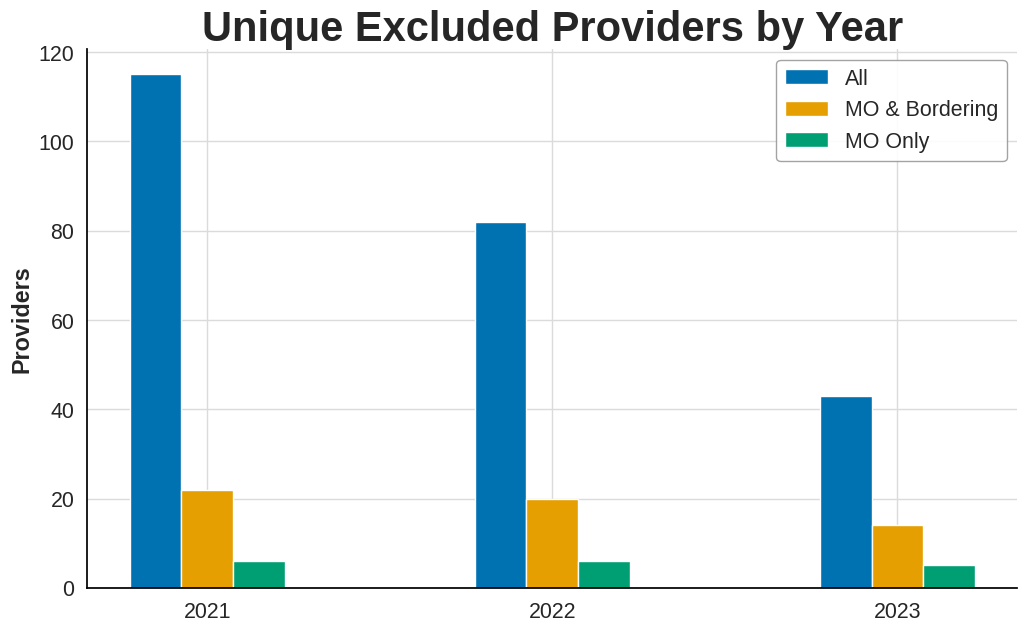

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the data
labels = df_yr_nat.index
nat_npi = df_yr_nat.npi
brd_npi = df_yr_brd.npi
mo_npi = df_yr_mo.npi

# 2. Set the position and width for the bars
x = np.arange(len(labels))  # the label locations
width = 0.45  # the width of the bars

# 3. Create the plot and bars
fig, ax = plt.subplots()
# Shift the first set of bars to the left
rects1 = ax.bar(x - width/3, nat_npi, width/3, label='All')
# Shift the second set of bars to the middle
rects2 = ax.bar(x, brd_npi, width/3, label='MO & Bordering')
# Shift the third set of bars to the right
rects3 = ax.bar(x + width/3, mo_npi, width/3, label='MO Only')

# 4. Add labels, title, and a legend
ax.set_ylabel('Providers')
ax.set_title('Unique Excluded Providers by Year')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Export/Save the plot
# plt.savefig('unique_prvdr_yr.png', bbox_inches='tight', dpi=300)

# 5. Display the plot
plt.show()

## Total Medicare payments by service type

In [17]:
# include target in groups so the indicator variable isn't aggregated
df_aapc = df[['npi','year','aapc_desc','tot_suplr_mdcr_pymt_amt','target']].groupby(['npi','year','aapc_desc','target']).sum().reset_index()
df_aapc.head()

,npi,year,aapc_desc,target,tot_suplr_mdcr_pymt_amt
0,1003000126,2021,Accessories for Oxygen Delivery Devices,0,1384.03
1,1003000126,2021,Oxygen Delivery Systems and Related Supplies,0,237.72
2,1003000126,2021,"Wheelchairs, Components, and Accessories",0,435.10
3,1003000126,2022,Accessories for Oxygen Delivery Devices,0,4069.40
4,1003000126,2022,Oxygen Delivery Systems and Related Supplies,0,727.83


### Which AAPC descriptions are present for confirmed fraudulent providers?

In [18]:
descs = df_aapc[df_aapc['target']==1]['aapc_desc'].unique()
descs

array(['Humidifiers and Nebulizers with Related Equipment',
       'Accessories for Oxygen Delivery Devices',
       'Enteral Feeding Supplies and Equipment',
       'Enteral Formulas and Additives',
       'Incontinence Devices and Supplies',
       'Oxygen Delivery Systems and Related Supplies',
       'Wheelchairs, Components, and Accessories',
       'Ostomy Pouches and Supplies',
       'Various Medical Supplies Including Tapes and Surgical Dressings',
       'Walking Aids and Attachments', 'Breathing Aids',
       'INFUSION PUMPS AND SUPPLIES', 'Inhalation Solutions',
       'Miscellaneous DME and Accessories',
       'Other Supplies Including Diabetes Supplies and Contraceptives',
       'Pharmacy Supply and Dispensing Fees',
       'Hospital Beds and Associated Supplies',
       'Traction and Other Orthopedic Devices',
       'Commode Chair and Supplies', 'Patient Lifts and Support Systems',
       'Pressure Mattresses, Pads, and Other Supplies', 'Safety Devices',
       'Wheel

In [19]:
len(descs)

64

Visualization will not be helpful if there are too few fraudulent providers for a given type of service. Which service types have at least 30 provider-year records for confirmed fraudelent providers?

In [20]:
num_exld_per_desc = df_aapc[df_aapc['target']==1].groupby('aapc_desc')['npi'].nunique().sort_values(ascending=False)
num_exld_per_desc[num_exld_per_desc >= 30]

aapc_desc
Other Supplies Including Diabetes Supplies and Contraceptives    57
Accessories for Oxygen Delivery Devices                          55
Oxygen Delivery Systems and Related Supplies                     44
Humidifiers and Nebulizers with Related Equipment                39
Wheelchairs, Components, and Accessories                         38
Pharmacy Supply and Dispensing Fees                              31
INFUSION PUMPS AND SUPPLIES                                      31
Name: npi, dtype: int64

For each service type with at least 30 records for confirmed fraudelent providers, do the distributions of total amounts paid by Medicare appear different between the fraud and non-fraud classes?

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


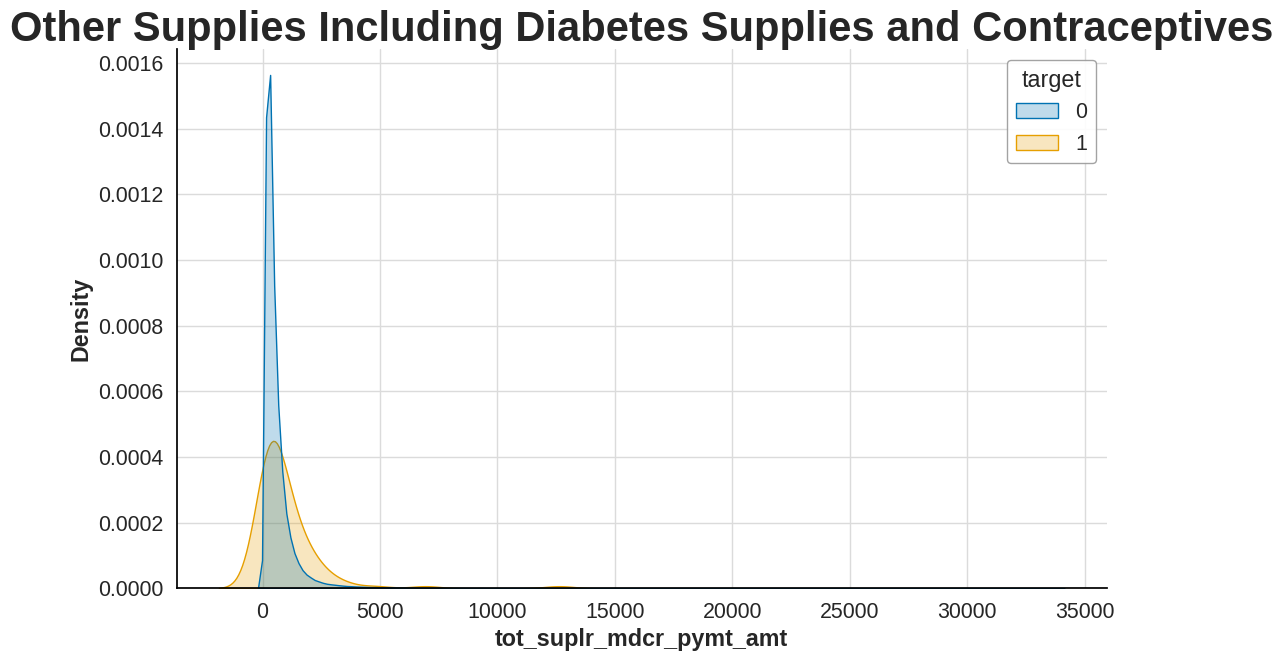

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


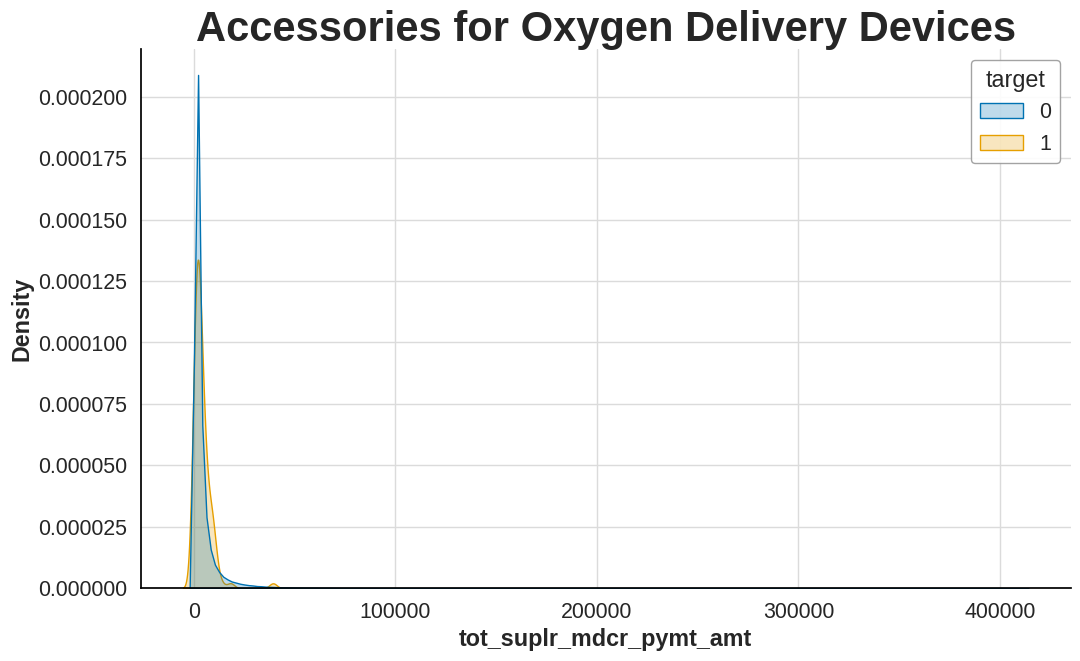

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


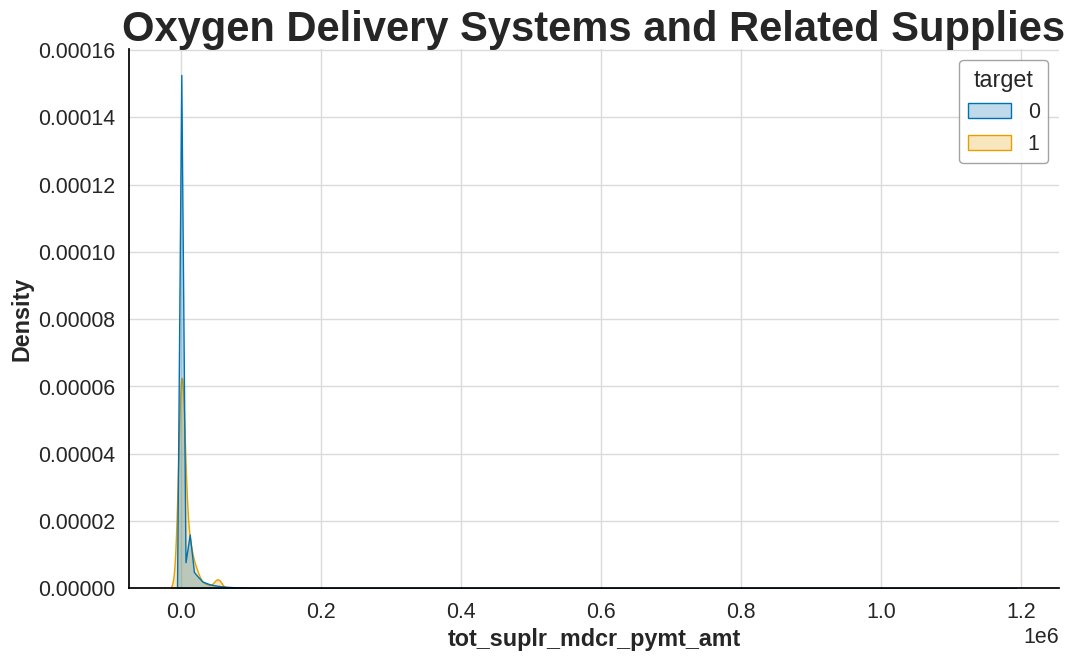

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


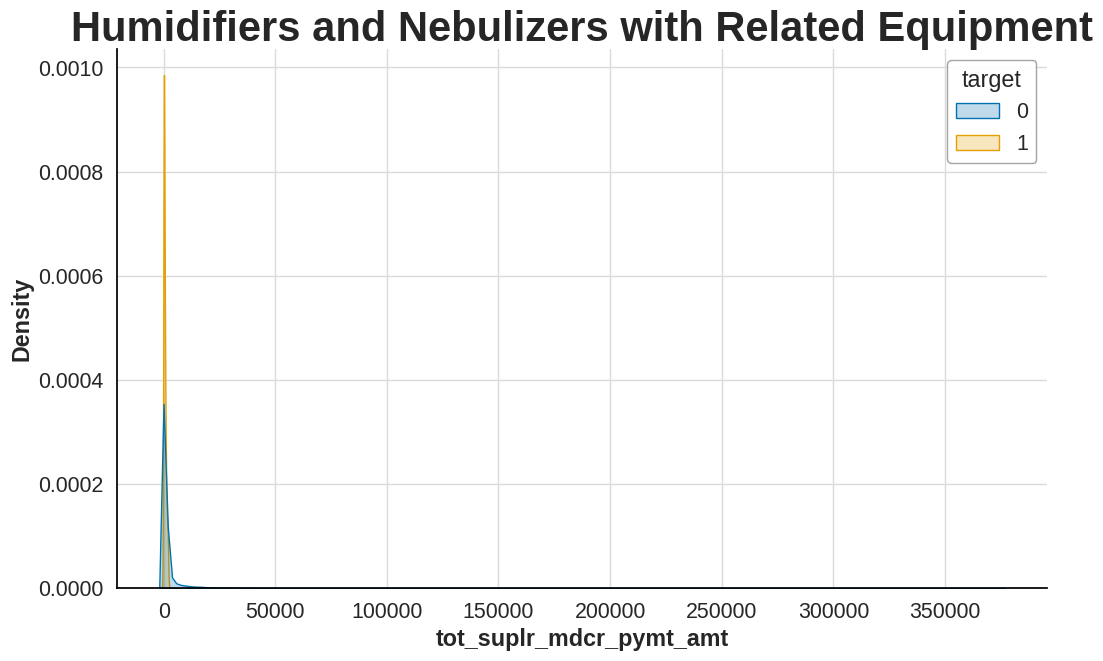

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


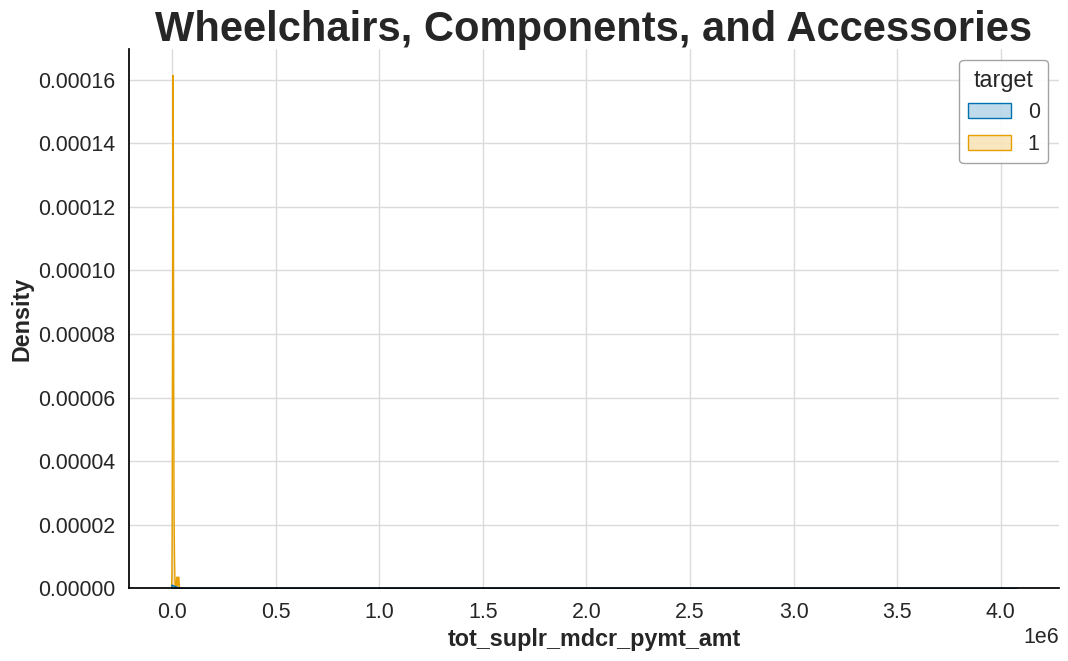

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


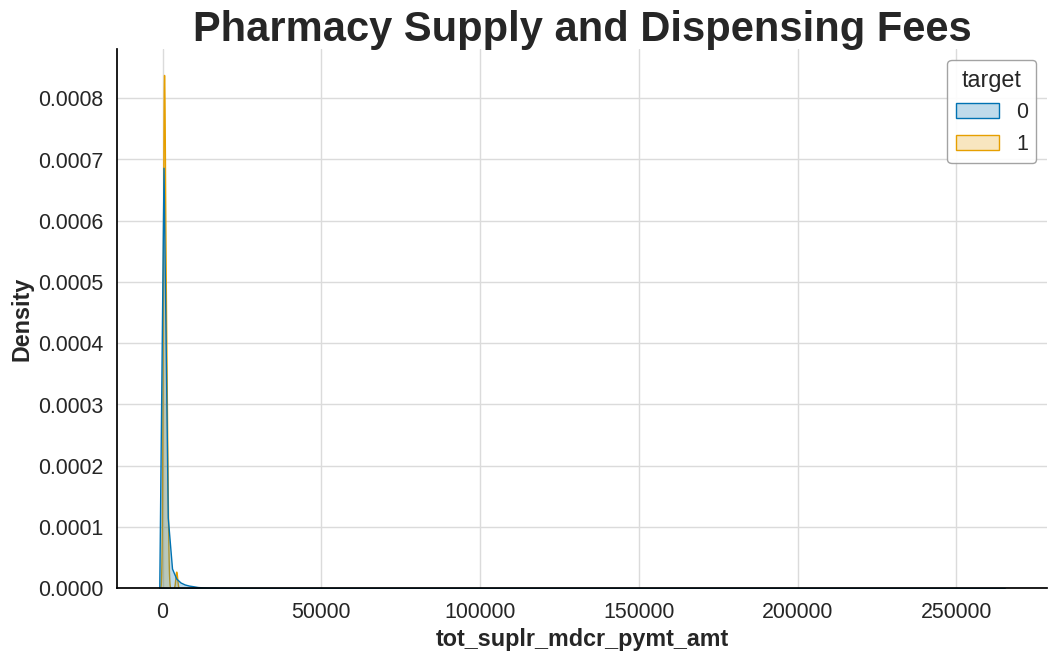

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


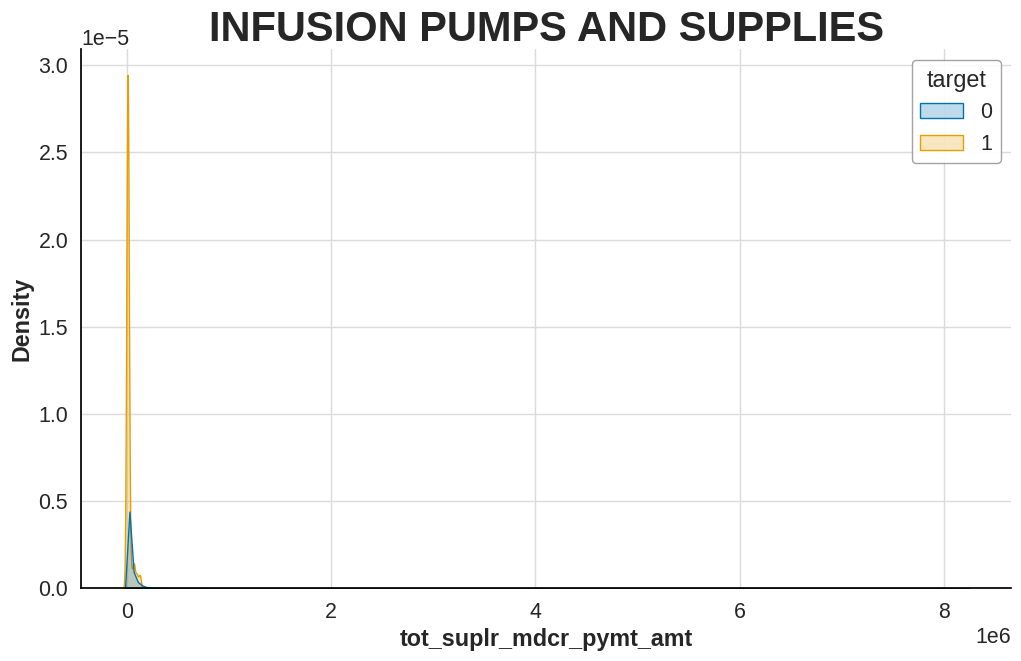

In [21]:
# Label graphs with AAPC descriptions
import seaborn as sns

descs = num_exld_per_desc[num_exld_per_desc >= 30].index

for desc in descs:
    sns.kdeplot(data=df_aapc[df_aapc['aapc_desc']==desc], x="tot_suplr_mdcr_pymt_amt", hue="target", fill=True, common_norm=False)
    plt.title(desc)
    plt.show()

In [22]:
# calculate means and std devs by year and aapc_desc grouping
df_aapc['avg_suplr_mdcr_pymt_amt_aapc'] = df_aapc.groupby(['year','aapc_desc'])['tot_suplr_mdcr_pymt_amt'].transform('mean')
df_aapc['std_suplr_mdcr_pymt_amt_aapc'] = df_aapc.groupby(['year','aapc_desc'])['tot_suplr_mdcr_pymt_amt'].transform('std')
# df_aapc.head()

In [23]:
# z-score of tot_suplr_mdcr_pymt_amt by year and aapc_desc grouping 
df_aapc['tot_suplr_mdcr_pymt_amt_aapc_z-scr'] = (df_aapc['tot_suplr_mdcr_pymt_amt'] - df_aapc['avg_suplr_mdcr_pymt_amt_aapc'])/df_aapc['std_suplr_mdcr_pymt_amt_aapc']
# df_aapc.head()

In [24]:
# drop the mean and std dev columns
df_aapc = df_aapc.drop(columns=['avg_suplr_mdcr_pymt_amt_aapc','std_suplr_mdcr_pymt_amt_aapc'])

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


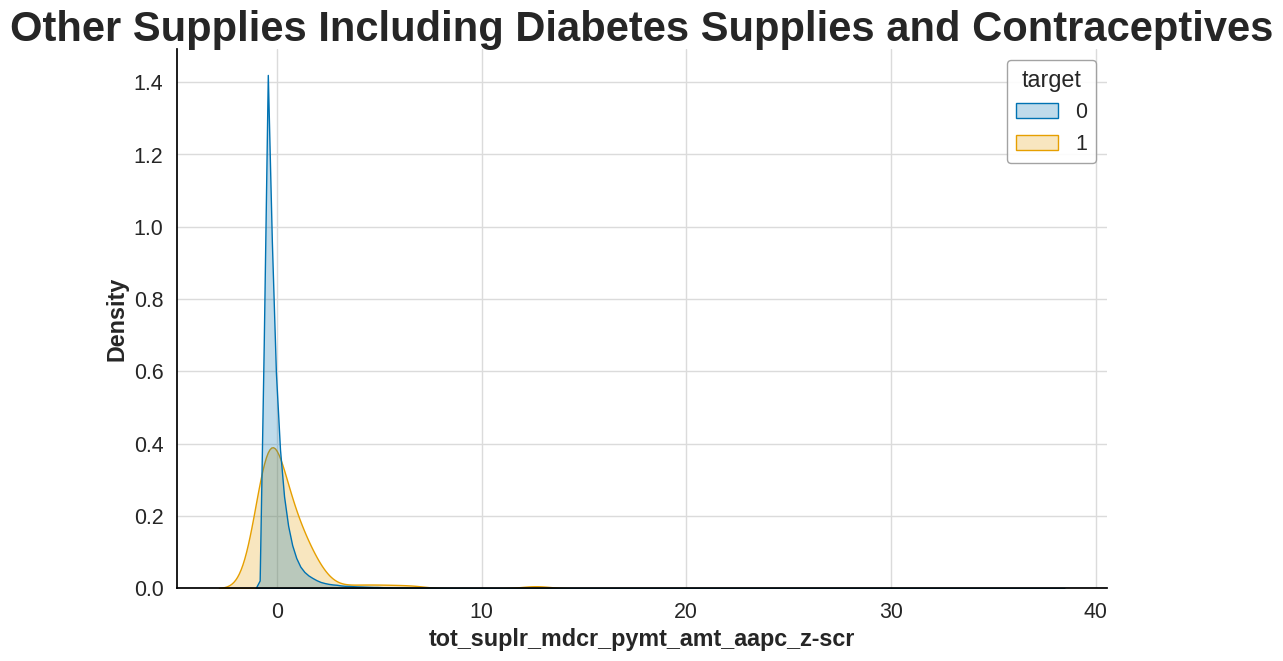

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


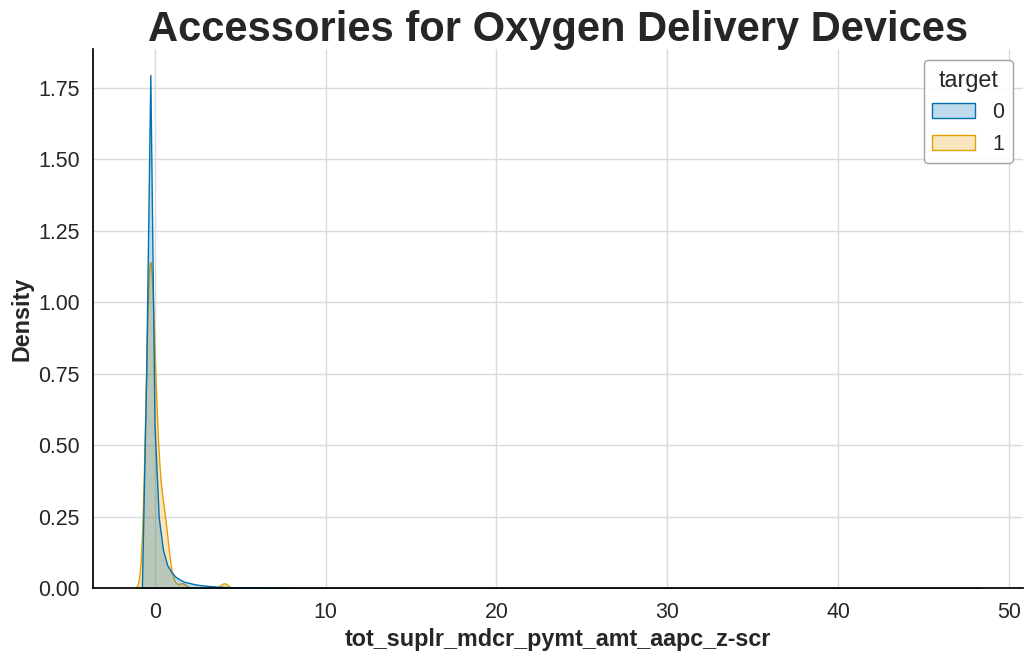

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


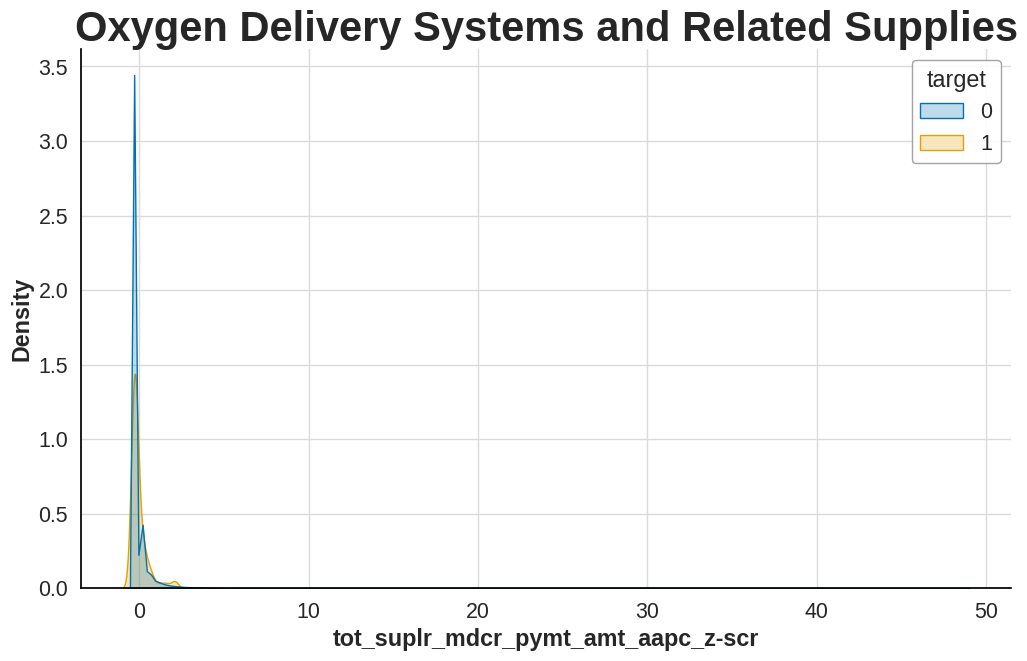

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


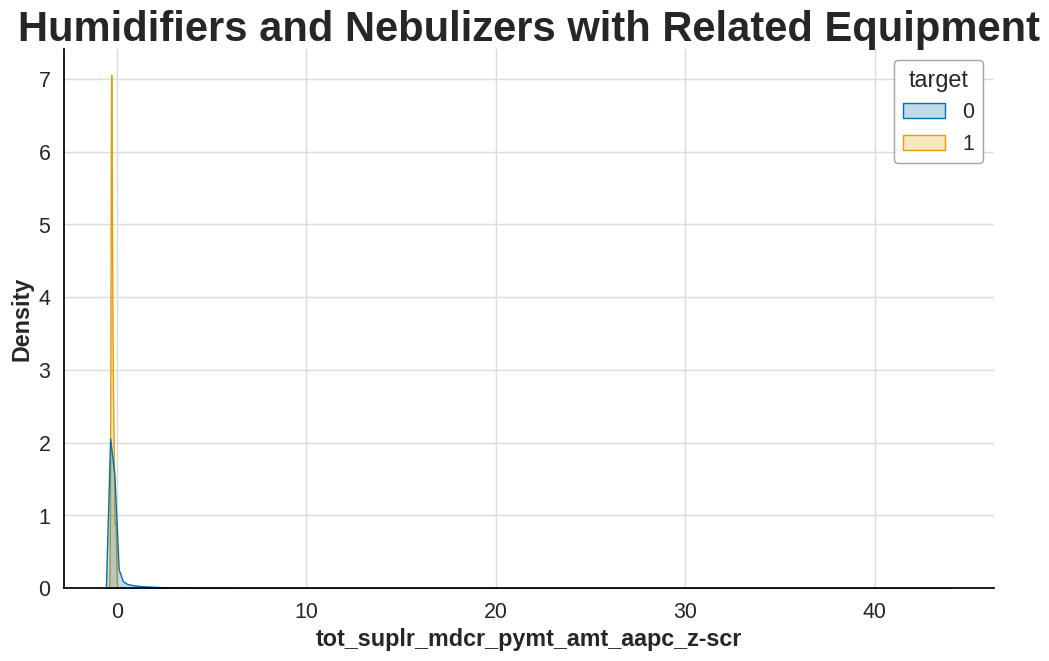

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


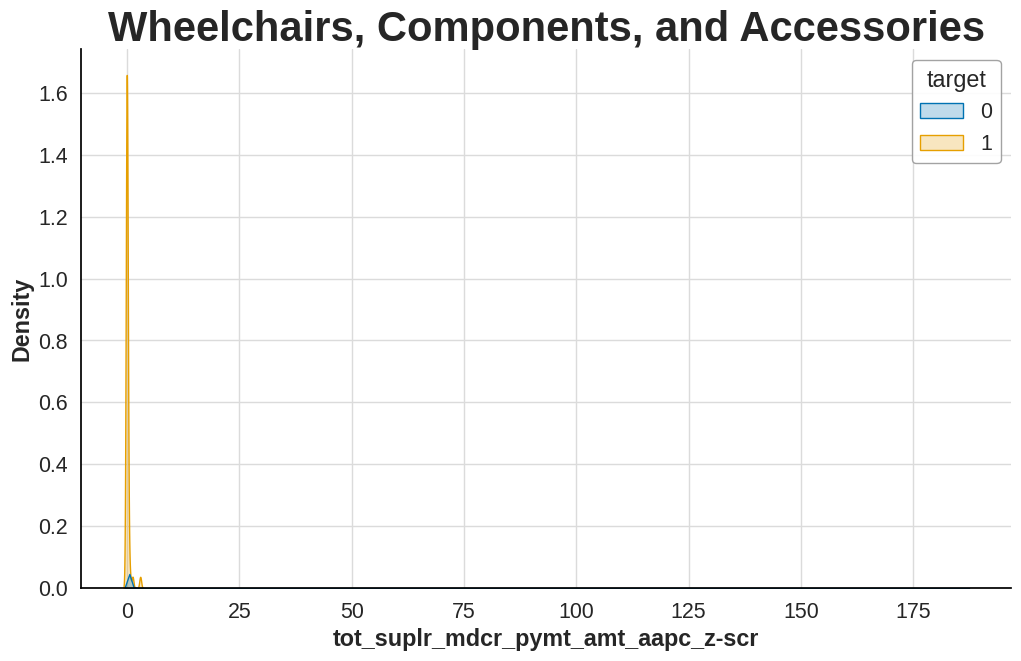

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


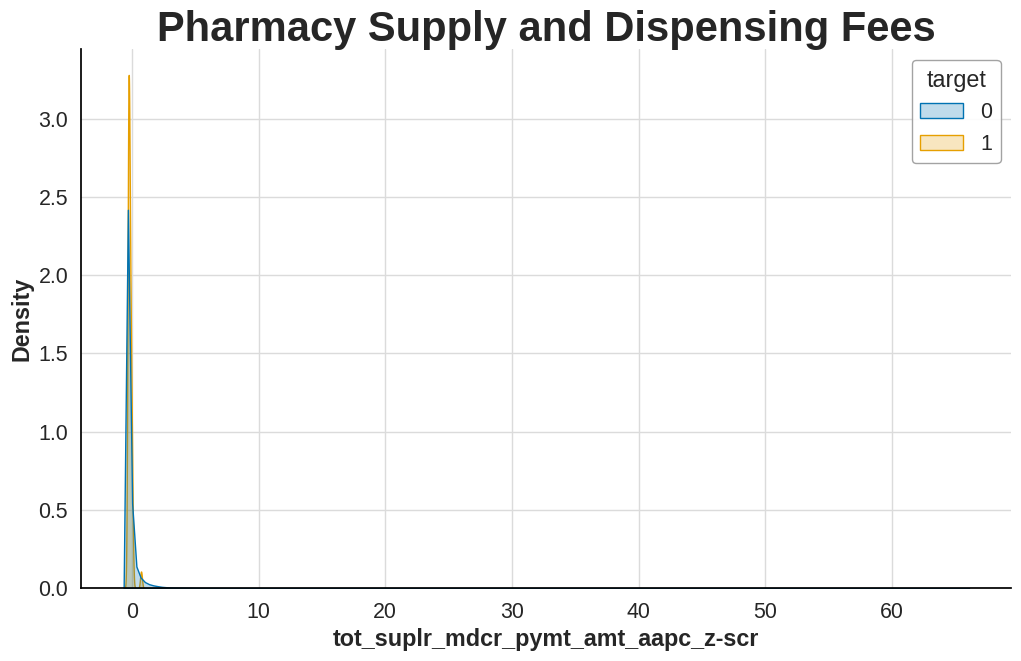

/opt/conda/lib/python3.11/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


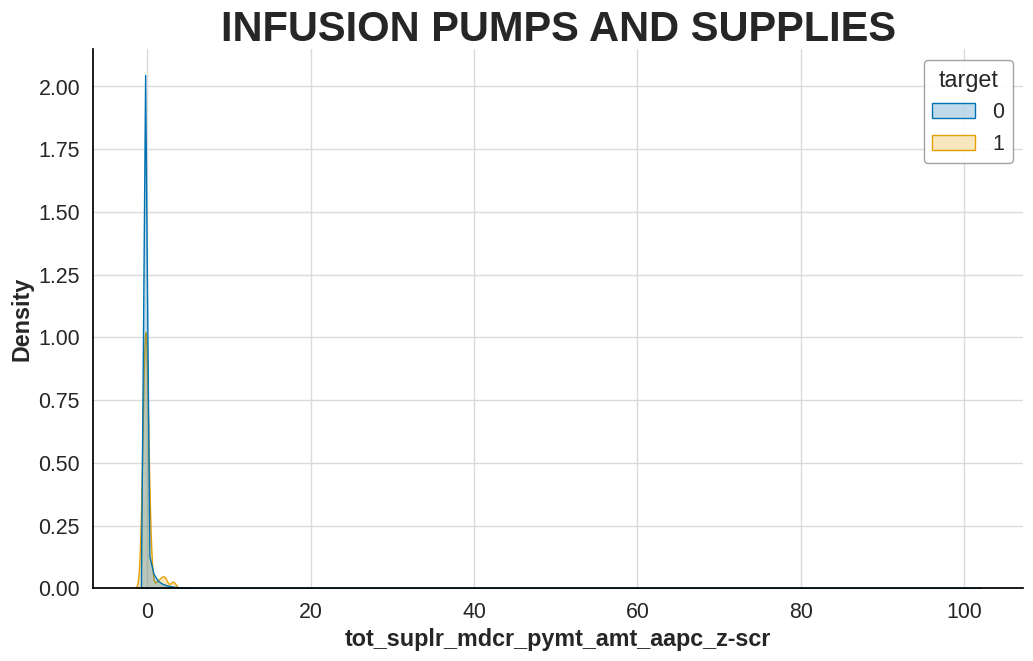

In [25]:
for desc in descs:
    sns.kdeplot(data=df_aapc[df_aapc['aapc_desc']==desc], x="tot_suplr_mdcr_pymt_amt_aapc_z-scr", hue="target", fill=True, common_norm=False)
    plt.title(desc)
    plt.show()

### Among high-risk services, is the mean total Medicare payment for providers with claims in only 2022 higher than that of other providers?

In [26]:
pivot = (
    df_aapc
    .pivot_table(
        index="npi",
        columns="year",
        values="tot_suplr_mdcr_pymt_amt",
        aggfunc="sum"
    )
    .fillna(0)
)

pivot.head()

year,2021,2022,2023
npi,,,
1003000126,2056.85,4797.23,3120.160000
1003000480,837.30,0.00,0.000000
1003000522,569.20,0.00,0.000000
1003000530,764.67,1068.21,1193.030000
1003000597,0.00,10077.68,60132.449999


In [27]:
# flag providers who received payments in 2022 only
spike_prvds = pivot[
    (pivot[2021] == 0) &
    (pivot[2023] == 0)
]

spike_prvds.head()

year,2021,2022,2023
npi,,,
1003002379,0.0,277.74,0.0
1003007469,0.0,8191.04,0.0
1003008236,0.0,730.76,0.0
1003010406,0.0,867.96,0.0
1003010786,0.0,1406.36,0.0


In [28]:
spike_list = list(spike_prvds.index)
len(spike_list) # how many?

23425

In [29]:
df_aapc_22 = df_aapc[df_aapc['year']==2022] # reduce dataframe to year 2022
df_aapc_22['spike'] = df_aapc_22['npi'].isin(spike_list) # flag the spike providers
df_aapc_22.head()

/tmp/ipykernel_308/4276761130.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aapc_22['spike'] = df_aapc_22['npi'].isin(spike_list) # flag the spike providers


,npi,year,aapc_desc,target,tot_suplr_mdcr_pymt_amt,tot_suplr_mdcr_pymt_amt_aapc_z-scr,spike
3,1003000126,2022,Accessories for Oxygen Delivery Devices,0,4069.40,-0.025509,False
4,1003000126,2022,Oxygen Delivery Systems and Related Supplies,0,727.83,-0.263619,False
12,1003000530,2022,Accessories for Oxygen Delivery Devices,0,811.14,-0.418872,False
13,1003000530,2022,Other Supplies Including Diabetes Supplies and...,0,206.10,-0.498322,False
14,1003000530,2022,Wheelchair Accessories,0,50.97,-0.041177,False


In [30]:
from scipy import stats

results = {}

for desc in descs:
    df_test = df_aapc_22[df_aapc_22['aapc_desc']==desc]
    control_data = df_test[df_test['spike']==False]['tot_suplr_mdcr_pymt_amt'] # non-spikes
    class_data = df_test[df_test['spike']==True]['tot_suplr_mdcr_pymt_amt'] # spike
    t_stat, p_val = stats.ttest_ind(class_data, control_data, equal_var=False)
    # convert to one-sided p-val
    p_val_one_tailed = p_val / 2
    results[desc] = (t_stat, p_val_one_tailed)

results

{'Other Supplies Including Diabetes Supplies and Contraceptives': (-139.1036695514998,
  0.0),
 'Accessories for Oxygen Delivery Devices': (-128.27344037051182, 0.0),
 'Oxygen Delivery Systems and Related Supplies': (-23.637876743606487,
  5.755085383185725e-117),
 'Humidifiers and Nebulizers with Related Equipment': (-76.36510629375118,
  0.0),
 'Wheelchairs, Components, and Accessories': (-11.37641580353475,
  3.0831836041786824e-30),
 'Pharmacy Supply and Dispensing Fees': (-60.494143395986995, 0.0),
 'INFUSION PUMPS AND SUPPLIES': (3.008686176606553, 0.0013431674739325286)}

Except for 'INFUSION PUMPS AND SUPPLIES' the mean amounta received from Medicare for services in these groupings are significantly higher among providers who received payments in years other than 2022.

### Who were the top providers of INFUSION PUMPS AND SUPPLIES services with a spike in 2022?

In [34]:
df_aapc_22_infsn = df_aapc_22[(df_aapc_22['aapc_desc']=='INFUSION PUMPS AND SUPPLIES') & (df_aapc_22['spike']==True)].sort_values(by='tot_suplr_mdcr_pymt_amt',ascending=False)
df_aapc_22_infsn.head(10)

,npi,year,aapc_desc,target,tot_suplr_mdcr_pymt_amt,tot_suplr_mdcr_pymt_amt_aapc_z-scr,spike
1438134,1528407186,2022,INFUSION PUMPS AND SUPPLIES,0,8.229490e+06,101.736770,True
975642,1356729040,2022,INFUSION PUMPS AND SUPPLIES,0,3.762057e+06,46.404891,True
1042390,1386623049,2022,INFUSION PUMPS AND SUPPLIES,0,3.689513e+06,45.506389,True
2435663,1891808390,2022,INFUSION PUMPS AND SUPPLIES,0,3.687434e+06,45.480641,True
1908051,1700129228,2022,INFUSION PUMPS AND SUPPLIES,0,3.660149e+06,45.142702,True
305465,1114183555,2022,INFUSION PUMPS AND SUPPLIES,0,3.337359e+06,41.144752,True
522318,1194162669,2022,INFUSION PUMPS AND SUPPLIES,0,3.268367e+06,40.290240,True
418580,1154403426,2022,INFUSION PUMPS AND SUPPLIES,0,3.218229e+06,39.669249,True
358637,1134147911,2022,INFUSION PUMPS AND SUPPLIES,0,3.041483e+06,37.480141,True
1620099,1598750424,2022,INFUSION PUMPS AND SUPPLIES,0,2.728487e+06,33.603501,True


In [36]:
# were any of the spike providers who received payments for INFUSION PUMPS AND SUPPLIES	convicted of fraud?
df_aapc_22_infsn['target'].sum()

0

In [37]:
# were any of the spike providers in 2022 convicted of fraud?
df_aapc_22_spk = df_aapc_22[df_aapc_22['spike']==True]
df_aapc_22_spk['target'].sum()

4

In [39]:
# who were they and which services did they receive payments for?
df_aapc_22_spk_frd = df_aapc_22_spk[df_aapc_22_spk['target']==1]
# join to original data by npi and year
df_22_spk_frd = df_aapc_22_spk_frd.merge(df, on=['npi','year'])
df_22_spk_frd

,npi,year,aapc_desc_x,target_x,tot_suplr_mdcr_pymt_amt_x,tot_suplr_mdcr_pymt_amt_aapc_z-scr,spike,rfrg_prvdr_last_name_org,rfrg_prvdr_first_name,rfrg_prvdr_mi,rfrg_prvdr_crdntls,rfrg_prvdr_ent_cd,rfrg_prvdr_st1,rfrg_prvdr_st2,rfrg_prvdr_city,rfrg_prvdr_state_abrvtn,rfrg_prvdr_state_fips,rfrg_prvdr_zip5,rfrg_prvdr_ruca_cat,rfrg_prvdr_ruca,rfrg_prvdr_ruca_desc,rfrg_prvdr_cntry,rfrg_prvdr_spclty_cd,rfrg_prvdr_spclty_desc,rfrg_prvdr_spclty_srce,rbcs_lvl,rbcs_id,rbcs_desc,hcpcs_cd,hcpcs_desc,suplr_rentl_ind,tot_suplrs,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt,aapc_desc_y,tot_suplr_mdcr_pymt_amt_y,target_y
0,1144242090,2022,Humidifiers and Nebulizers with Related Equipment,1,67.59,-0.318687,True,Anukwu,Linus,U,md,I,4500 Memorial Dr,NaN,Belleville,IL,17,62226,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DE000N,DME-Other DME,E0570,"Nebulizer, with compressor",Y,1,5.0,12,12,50.730000,7.952500,5.632500,5.465000,Humidifiers and Nebulizers with Related Equipment,67.59,1
1,1295721876,2022,Other Supplies Including Diabetes Supplies and...,1,13.66,-0.750221,True,Gray,Janette,J,md,I,3636 Fifth Avenue,Ste 300,San Diego,CA,06,92103,Urban,1.0,Metropolitan area core: primary flow within an...,US,11,internal_medicine,Claim-Specialty,Durable Medical Equipment,DA000N,DME-Medical/Surgical Supplies,A4259,"Lancets, per box of 100",N,2,5.0,13,13,32.384615,1.432308,1.050769,1.033077,Other Supplies Including Diabetes Supplies and...,13.66,1
2,1447286158,2022,"Wheelchairs, Components, and Accessories",1,149.78,-0.069620,True,Aboughali,Wael,A,md,I,1602 Garth Rd,NaN,Baytown,TX,48,77520,Urban,1.0,Metropolitan area core: primary flow within an...,US,08,family_practice,Claim-Specialty,Durable Medical Equipment,DD000N,DME-Wheelchairs,K0001,Standard wheelchair,Y,1,5.0,11,11,77.690000,17.216364,13.616364,20.491818,"Wheelchairs, Components, and Accessories",149.78,1
3,1851301204,2022,Shoulder Orthotics,1,992.83,-0.679566,True,Young,David,NaN,md,I,1020 S State Highway 16,NaN,Fredericksburg,TX,48,78624,Rural,4.0,Micropolitan area core: primary flow within an...,US,93,emergency_medicine,Claim-Specialty,Orthotic Devices,DF000N,DME-Orthotic Devices,L3670,"Shoulder orthosis, acromio/clavicular (canvas ...",N,1,11.0,11,11,136.010000,113.340000,90.257273,95.080000,Shoulder Orthotics,992.83,1


## Wilcoxon rank-sum tests on numeric features
All features right of and including `tot_suplrs` except `year`, `aapc_desc`, and `target`.

In [3]:
df_num = df.loc[:,'tot_suplrs':'target']
df_num = df_num.drop(columns=['year','aapc_desc'])
df_num.head()

,tot_suplrs,tot_suplr_benes,tot_suplr_clms,tot_suplr_srvcs,avg_suplr_sbmtd_chrg,avg_suplr_mdcr_alowd_amt,avg_suplr_mdcr_pymt_amt,avg_suplr_mdcr_stdzd_amt,tot_suplr_mdcr_pymt_amt,tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr,avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat,target
0,5,5.0,16,16,46.336250,20.097500,14.857500,15.280000,237.72,-0.425926,0.955638,0
1,6,5.0,19,19,360.770000,98.223158,72.843684,79.753158,1384.03,-0.347468,0.942913,0
2,1,5.0,11,11,92.000000,39.230000,31.385455,33.552727,345.24,-0.390508,0.985031,0
3,1,5.0,11,11,20.000000,10.210909,8.169091,8.456364,89.86,-0.409305,1.022396,0
4,4,5.0,11,13,272.003846,80.513846,64.407692,84.701538,837.30,-0.419031,0.772909,0


In [4]:
feats = df_num.columns[:-1]
feats

Index(['tot_suplrs', 'tot_suplr_benes', 'tot_suplr_clms', 'tot_suplr_srvcs',
       'avg_suplr_sbmtd_chrg', 'avg_suplr_mdcr_alowd_amt',
       'avg_suplr_mdcr_pymt_amt', 'avg_suplr_mdcr_stdzd_amt',
       'tot_suplr_mdcr_pymt_amt',
       'tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr',
       'avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat'],
      dtype='object')

In [5]:
from scipy import stats

results = {}

for feat in feats:
    stat, pval = stats.ranksums(df_num[df_num['target']==1][feat], df_num[df_num['target']==0][feat])
    results[feat] = (stat, pval)

results

{'tot_suplrs': (0.6041464627830544, 0.5457462712355434),
 'tot_suplr_benes': (1.188293090174605, 0.23471795908127624),
 'tot_suplr_clms': (0.3785443708072486, 0.7050262385089077),
 'tot_suplr_srvcs': (2.331912432806316, 0.01970529828961795),
 'avg_suplr_sbmtd_chrg': (-3.655359690038252, 0.00025682164198065295),
 'avg_suplr_mdcr_alowd_amt': (-1.7671836267036045, 0.07719748085894475),
 'avg_suplr_mdcr_pymt_amt': (-2.062863587675007, 0.03912559050252428),
 'avg_suplr_mdcr_stdzd_amt': (-2.5683917236237996, 0.010217162547512346),
 'tot_suplr_mdcr_pymt_amt': (-0.7509853597546738, 0.4526614666715598),
 'tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr': (3.9761774646108,
  7.003187217641439e-05),
 'avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat': (3.226854026912556,
  0.0012515929328168725)}

The Wilcoxon rank-sum test shows that `avg_suplr_sbmtd_chrg` tends to be lower for fraudulent providers with the greatest significance. It also shows that `tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr` tends to be greater for fraudulent providers with greatest significance.

### Do the class differences hold after filtering for MO and bordering states?

In [6]:
df_brd = df[df.rfrg_prvdr_state_abrvtn.isin(['MO', 'IL', 'IA', 'OK', 'AR', 'TN', 'KS', 'NE', 'KY'])]
df_brd_num = df_brd.loc[:,'tot_suplrs':'target']
df_brd_num = df_brd_num.drop(columns=['year','aapc_desc'])

feats = df_num.columns[:-1]

results = {}

for feat in feats:
    stat, pval = stats.ranksums(df_brd_num[df_brd_num['target']==1][feat], df_brd_num[df_brd_num['target']==0][feat])
    results[feat] = (stat, pval)

results

{'tot_suplrs': (1.4209442812541524, 0.15533295836154865),
 'tot_suplr_benes': (1.5958490049866174, 0.11052250918628632),
 'tot_suplr_clms': (3.494586764577786, 0.00047479625609440923),
 'tot_suplr_srvcs': (5.180954808308749, 2.2075297564592287e-07),
 'avg_suplr_sbmtd_chrg': (-4.378821481210752, 1.193228233865733e-05),
 'avg_suplr_mdcr_alowd_amt': (-2.1531950848242194, 0.03130334981121935),
 'avg_suplr_mdcr_pymt_amt': (-2.12869022917707, 0.033279897761656296),
 'avg_suplr_mdcr_stdzd_amt': (-2.7588009649065013, 0.005801385707492467),
 'tot_suplr_mdcr_pymt_amt': (3.3987306693773265, 0.0006769934774770841),
 'tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr': (6.522206510729948,
  6.9280535704715e-11),
 'avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat': (4.484562395437618,
  7.306372452398345e-06)}

While it holds that `avg_suplr_sbmtd_chrg` and `tot_suplr_mdcr_pymt_amt_hcpcs_rentl_ind_z_scr` tend to be lower and higher respectively for fraudenlent providers in MO and bordering states with a high degree of significance. It emerges that `tot_suplr_clms`, `tot_suplr_srvcs`, `tot_suplr_mdcr_pymt_amt`, and `avg_suplr_mdcr_alowd_amt_hcpcs_rentl_ind_rat` all tend to be greater for fraudenlent providers in MO and bordering states with high significance.